In [ ]:
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
from sklearn.preprocessing import MinMaxScaler
import cv2
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

zip_path = "/content/drive/MyDrive/Training_database_float16.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())

['Training_database_float16/parallel_02000_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02001_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02002_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02003_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02004_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02005_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02006_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02007_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02008_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02009_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02010_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02011_straight_opposite_clean_field.npz', 'Training_database_float16/parallel_02012_straight_opposite_cle

In [ ]:
extraction_dir = "extracted_zip_contents"
os.makedirs(extraction_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extraction_dir)

print(f"Contents extracted to: {extraction_dir}")
print("Listing extracted files:")
for root, dirs, files in os.walk(extraction_dir):
    for file in files:
        print(os.path.join(root, file))

Contents extracted to: extracted_zip_contents
Listing extracted files:
extracted_zip_contents/Training_database_float16/sample_00673_offset_straight_clean_field.npz
extracted_zip_contents/Training_database_float16/sample_00189_perfect_straight_clean_field.npz
extracted_zip_contents/Training_database_float16/parallel_02225_straight_opposite_noisy_field.npz
extracted_zip_contents/Training_database_float16/sample_00028_perfect_straight_clean_field.npz
extracted_zip_contents/Training_database_float16/parallel_02460_curved_opposite_noisy_field.npz
extracted_zip_contents/Training_database_float16/parallel_02459_curved_opposite_noisy_field.npz
extracted_zip_contents/Training_database_float16/sample_02731_no_pipe_straight_clean_field.npz
extracted_zip_contents/Training_database_float16/sample_00184_perfect_straight_clean_field.npz
extracted_zip_contents/Training_database_float16/sample_00343_perfect_straight_noisy_field.npz
extracted_zip_contents/Training_database_float16/parallel_02080_straig

In [ ]:
folder = "/content/extracted_zip_contents/Training_database_float16/"

npz_test = np.load(folder + "sample_00000_perfect_straight_clean_field.npz")
data_test_un = npz_test["data"]
print(data_test_un.shape)
print(data_test_un.dtype)
print(type(data_test_un))


(853, 901, 4)
float16
<class 'numpy.ndarray'>


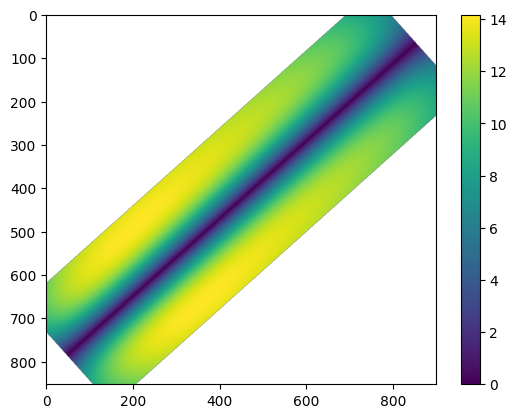

In [ ]:
plt.imshow(data_test_un.astype(np.float32)[..., 2])
plt.colorbar()

In [ ]:
npz_test = np.load(folder + "sample_01200_no_pipe_straight_clean_field.npz")
data_test_zero = npz_test["data"]
print(data_test_zero.shape)
print(data_test_zero.dtype)
print(type(data_test_zero))

(1443, 1347, 4)
float16
<class 'numpy.ndarray'>


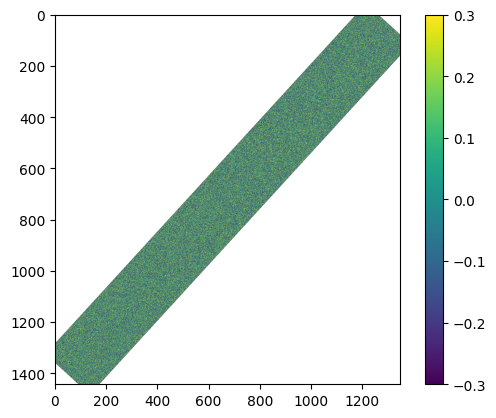

In [ ]:
plt.imshow(data_test_zero.astype(np.float32)[..., 2])
plt.colorbar()

In [ ]:
target_dir = '/content/extracted_zip_contents/Training_database_float16/'
csv_files = glob.glob(os.path.join(target_dir, '*.csv'))

if csv_files:
    print(f'Found CSV files: {csv_files}')
    df = pd.read_csv(csv_files[0], sep=';')
else:
    print('No CSV files found in that directory.')

Found CSV files: ['/content/extracted_zip_contents/Training_database_float16/pipe_detection_label.csv']


In [ ]:
df[df["label"] == 1].head()

,field_file,label,width_m,coverage_type,shape,noisy,noise_type,pipe_type
0,sample_00000_perfect_straight_clean_field.npz,1,62.40,perfect,straight,False,NaN,single
1,sample_00001_perfect_straight_clean_field.npz,1,41.08,perfect,straight,False,NaN,single
2,sample_00002_perfect_straight_clean_field.npz,1,42.34,perfect,straight,False,NaN,single
3,sample_00003_perfect_straight_clean_field.npz,1,4.96,perfect,straight,False,NaN,single
4,sample_00004_perfect_straight_clean_field.npz,1,35.96,perfect,straight,False,NaN,single


In [ ]:
df[df["label"] == 0].head()

,field_file,label,width_m,coverage_type,shape,noisy,noise_type,pipe_type
1200,sample_01200_no_pipe_straight_clean_field.npz,0,46.86,no_pipe,straight,False,uniform,single
1201,sample_01201_no_pipe_straight_clean_field.npz,0,10.09,no_pipe,straight,False,gaussian,single
1202,sample_01202_no_pipe_straight_clean_field.npz,0,23.89,no_pipe,straight,False,colored,single
1203,sample_01203_no_pipe_straight_clean_field.npz,0,38.56,no_pipe,straight,False,colored,single
1204,sample_01204_no_pipe_straight_clean_field.npz,0,15.81,no_pipe,straight,False,uniform,single


In [ ]:
print(len(df))

2833


ETAPE 3

In [ ]:
input_folder = "/content/extracted_zip_contents/Training_database_float16/"
output_folder = "/content/extracted_zip_contents_resized/"
os.makedirs(output_folder, exist_ok=True)

TARGET_SHAPE = (64, 64, 4)

for npz_path in glob.glob(os.path.join(input_folder, "*.npz")):
    with np.load(npz_path) as data:
        key = list(data.keys())[0]
        arr = data[key]

    resized = np.resize(arr, TARGET_SHAPE)

    out_path = os.path.join(output_folder, os.path.basename(npz_path))
    np.savez_compressed(out_path, **{key: resized})

    print(f"{os.path.basename(npz_path)} -> {resized.shape}")

sample_00673_offset_straight_clean_field.npz -> (64, 64, 4)
sample_00189_perfect_straight_clean_field.npz -> (64, 64, 4)
parallel_02225_straight_opposite_noisy_field.npz -> (64, 64, 4)
sample_00028_perfect_straight_clean_field.npz -> (64, 64, 4)
parallel_02460_curved_opposite_noisy_field.npz -> (64, 64, 4)
parallel_02459_curved_opposite_noisy_field.npz -> (64, 64, 4)
sample_02731_no_pipe_straight_clean_field.npz -> (64, 64, 4)
sample_00184_perfect_straight_clean_field.npz -> (64, 64, 4)
sample_00343_perfect_straight_noisy_field.npz -> (64, 64, 4)
parallel_02080_straight_opposite_clean_field.npz -> (64, 64, 4)
parallel_02305_straight_same_clean_field.npz -> (64, 64, 4)
parallel_02018_straight_opposite_clean_field.npz -> (64, 64, 4)
sample_01199_missed_curved_noisy_field.npz -> (64, 64, 4)
sample_01050_missed_straight_clean_field.npz -> (64, 64, 4)
sample_00229_perfect_straight_noisy_field.npz -> (64, 64, 4)
sample_01262_no_pipe_straight_clean_field.npz -> (64, 64, 4)
sample_00528_offset

In [ ]:
final_df = df.drop(["coverage_type", "shape", "noisy", "noise_type", "pipe_type"], axis=1)

In [ ]:
final_df.head()

,field_file,label,width_m
0,sample_00000_perfect_straight_clean_field.npz,1,62.40
1,sample_00001_perfect_straight_clean_field.npz,1,41.08
2,sample_00002_perfect_straight_clean_field.npz,1,42.34
3,sample_00003_perfect_straight_clean_field.npz,1,4.96
4,sample_00004_perfect_straight_clean_field.npz,1,35.96


In [ ]:
df_majority = final_df[final_df["label"] == 1]
df_minority = final_df[final_df["label"] == 0]

In [ ]:
input_folder_resized = "/content/extracted_zip_contents_resized/"

all_arrays = []
for npz_path in glob.glob(os.path.join(input_folder_resized, "*.npz")):
    with np.load(npz_path) as data:
        key = list(data.keys())[0]
        all_arrays.append(data[key][..., 2])

X_array = np.concatenate(all_arrays).reshape(len(all_arrays), -1)
print(f"Shape : {X_array.shape}")

X_clean = np.nan_to_num(X_array, nan=0.0)
X_scaled = MinMaxScaler().fit_transform(X_clean)

pca = PCA(n_components=2833)
pca.fit(X_scaled)

print(f"Variance expliquée : {pca.explained_variance_ratio_.round(4)}")
print(f"Cumulée            : {np.cumsum(pca.explained_variance_ratio_).round(4)}")

Shape : (2833, 4096)
Variance expliquée : [0.2582 0.0694 0.0256 ... 0.     0.     0.    ]
Cumulée            : [0.2582 0.3276 0.3532 ... 1.     1.     1.    ]


In [ ]:
#donnée de test


zip_path_real_data = "/content/drive/MyDrive/real_data.zip"

with zipfile.ZipFile(zip_path_real_data, 'r') as z:
    print(z.namelist())

extraction_dir_real_data = "extracted_zip_contents_real_data"
os.makedirs(extraction_dir_real_data, exist_ok=True)

with zipfile.ZipFile(zip_path_real_data, 'r') as z:
    z.extractall(extraction_dir_real_data)

print(f"Contents extracted to: {extraction_dir_real_data}")
print("Listing extracted files:")
for root, dirs, files in os.walk(extraction_dir_real_data):
    for file in files:
        print(os.path.join(root, file))

['real_data_00000.npz', 'real_data_00001.npz', 'real_data_no_pipe_00050.npz', 'real_data_no_pipe_00049.npz', 'real_data_no_pipe_00048.npz', 'real_data_no_pipe_00047.npz', 'real_data_no_pipe_00046.npz', 'real_data_no_pipe_00045.npz', 'real_data_no_pipe_00044.npz', 'real_data_no_pipe_00043.npz', 'real_data_no_pipe_00042.npz', 'real_data_no_pipe_00041.npz', 'real_data_no_pipe_00040.npz', 'real_data_no_pipe_00039.npz', 'real_data_no_pipe_00038.npz', 'real_data_no_pipe_00037.npz', 'real_data_no_pipe_00036.npz', 'real_data_no_pipe_00035.npz', 'real_data_no_pipe_00034.npz', 'real_data_no_pipe_00033.npz', 'real_data_no_pipe_00032.npz', 'real_data_no_pipe_00031.npz', 'real_data_no_pipe_00030.npz', 'real_data_no_pipe_00029.npz', 'real_data_no_pipe_00028.npz', 'real_data_no_pipe_00027.npz', 'real_data_no_pipe_00026.npz', 'real_data_no_pipe_00025.npz', 'real_data_no_pipe_00024.npz', 'real_data_no_pipe_00023.npz', 'real_data_no_pipe_00022.npz', 'real_data_no_pipe_00021.npz', 'real_data_no_pipe_0002

In [ ]:
input_folder_real_data = "/content/extracted_zip_contents/real_data.zip/"
output_folder_real_data = "/content/extracted_zip_contents_real_data"

os.makedirs(output_folder_real_data, exist_ok=True)

TARGET_SHAPE = (64, 64, 4)

for npz_path in glob.glob(os.path.join(input_folder_real_data, "*.npz")):
    with np.load(npz_path) as data:
        key = list(data.keys())[0]
        arr = data[key]

    resized = np.resize(arr, TARGET_SHAPE)

    out_path = os.path.join(output_folder_real_data, os.path.basename(npz_path))
    np.savez_compressed(out_path, **{key: resized})

    print(f"{os.path.basename(npz_path)} -> {resized.shape}")

In [ ]:
df_real_data = pd.read_csv("/content/extracted_zip_contents_real_data/pipe_presence_width_detection_label.csv", sep=';')

final_df_real_data = df_real_data.drop(["coverage_type", "shape", "noisy", "noise_type", "pipe_type"], axis=1)

In [ ]:
#input_folder_resized_real_data = "/content/extracted_zip_contents_real_data/"
#
#all_arrays_real_data = []
#for npz_path in glob.glob(os.path.join(input_folder_resized_real_data, "*.npz")):
 #   with np.load(npz_path) as data:
 #       key = list(data.keys())[0]
 #       all_arrays_real_data.append(data[key][..., 2])
#
#X_array_real_data = np.concatenate(all_arrays_real_data).reshape(len(all_arrays_real_data), -1)
#print(f"Shape : {X_array_real_data.shape}")

#X_clean_real_data = np.nan_to_num(X_array_real_data, nan=0.0)
#X_scaled_real_data = MinMaxScaler().fit_transform(X_clean_real_data)

ETAPE 4

In [ ]:
input_folder_resized = "/content/extracted_zip_contents_resized/"
input_folder_resized_real_data = "/content/extracted_zip_contents_real_data/"

TARGET_SHAPE = (64, 64, 4)

all_arrays, fnames_train = [], []
for npz_path in glob.glob(os.path.join(input_folder_resized, "*.npz")):
    with np.load(npz_path) as data:
        key = list(data.keys())[0]
        arr = np.resize(data[key], TARGET_SHAPE)
        all_arrays.append(arr[..., 2])
    fnames_train.append(os.path.basename(npz_path))

X_array = np.concatenate(all_arrays).reshape(len(all_arrays), -1)
X_clean = np.nan_to_num(X_array, nan=0.0)

all_arrays_real_data, fnames_test = [], []
for npz_path in glob.glob(os.path.join(input_folder_resized_real_data, "*.npz")):
    with np.load(npz_path) as data:
        key = list(data.keys())[0]
        arr = np.resize(data[key], TARGET_SHAPE)
        all_arrays_real_data.append(arr[..., 2])
    fnames_test.append(os.path.basename(npz_path))

X_array_real_data = np.concatenate(all_arrays_real_data).reshape(len(all_arrays_real_data), -1)
X_clean_real_data = np.nan_to_num(X_array_real_data, nan=0.0)

df_train = final_df.set_index("field_file")
df_test = final_df_real_data.set_index("field_file")

y_train = df_train.loc[fnames_train, "label"].values
widths_train = df_train.loc[fnames_train, "width_m"].values.reshape(-1, 1)

y_test = df_test.loc[fnames_test, "label"].values
widths_test = df_test.loc[fnames_test, "width_m"].values.reshape(-1, 1)

features_train = np.concatenate([X_clean, widths_train], axis=1)
features_test = np.concatenate([X_clean_real_data, widths_test], axis=1)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(features_train)
X_test_scaled = scaler.transform(features_test)

X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)

pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(np.nan_to_num(X_train_scaled, nan=0.0))
X_test_pca = pca.transform(np.nan_to_num(X_test_scaled, nan=0.0))

print(f"Après PCA : {X_train_pca.shape}")
print(f"Variance cumulée : {np.cumsum(pca.explained_variance_ratio_)[-1]:.4f}")

param_grid = {
    "n_neighbors": [i for i in range(0, 101) if i % 2 != 0]
}

cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=99)
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv,
                    scoring="f1_weighted", n_jobs=1, verbose=1)
grid.fit(X_train_pca, y_train)

print(f"Meilleurs params : {grid.best_params_}")
print(f"Meilleur F1 CV   : {grid.best_score_:.4f}")

y_pred = grid.best_estimator_.predict(X_test_pca)
print(f"\nF1 test (weighted) : {f1_score(y_test, y_pred, average='weighted'):.4f}")

Après PCA : (2833, 50)
Variance cumulée : 0.7842
Fitting 3 folds for each of 50 candidates, totalling 150 fits
Meilleurs params : {'n_neighbors': 5}
Meilleur F1 CV   : 0.9028

F1 test (weighted) : 0.9607
